# Forecasting to 2035

## Project: Albania Brain Drain Analysis

In this notebook, we forecast key indicators to 2035.

The main indicators forecasted in this notebook are:

1. Population
2. Net migration
3. First residence permits

The models used are:

- Moving average baseline
- Linear Regression
- ARIMA

Important: Forecasts are not predictions with certainty. They are scenario-based estimates based on past trends.

## Imports and Paths

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

ROOT_DIR = Path.cwd().parent
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
VISUALS_DIR = ROOT_DIR / "visuals"
REPORTS_DIR = ROOT_DIR / "reports"

VISUALS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT_DIR)
print("Processed:", PROCESSED_DIR)
print("Visuals:", VISUALS_DIR)
print("Reports:", REPORTS_DIR)

Root: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis
Processed: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed
Visuals: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\visuals
Reports: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\reports


In [2]:
%pip install scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.


## Load Master Dataset

In [3]:
master = pd.read_csv(PROCESSED_DIR / "master_analysis_dataset.csv")

master = master.sort_values("year").reset_index(drop=True)

print("Rows:", master.shape[0])
print("Columns:", master.shape[1])

master.head()

Rows: 26
Columns: 22


,year,fdi_percent_gdp,gdp_current_usd,gdp_growth_annual_percent,gdp_per_capita_current_usd,net_migration,population_growth_annual_percent,population_total,remittances_percent_gdp,unemployment_total_percent,...,total_first_residence_permits,education_permits,employment_permits,family_permits,net_migration_rate_per_1000,residence_permits_per_100k_population,employment_permit_share,education_permit_share,family_permit_share,migration_pressure_index
0,2000,3.989321,3.584570e+09,7.462859,1160.420471,-60531.0,-0.637357,3089027.0,16.677034,19.023,...,NaN,NaN,NaN,NaN,-19.595491,NaN,NaN,NaN,NaN,19.595491
1,2001,5.107089,4.059064e+09,8.863731,1326.416524,-48070.0,-0.938470,3060173.0,17.228110,18.570,...,NaN,NaN,NaN,NaN,-15.708262,NaN,NaN,NaN,NaN,15.708262
2,2002,2.990031,4.515003e+09,4.628396,1479.838846,-45178.0,-0.299877,3051010.0,16.247386,17.891,...,NaN,NaN,NaN,NaN,-14.807556,NaN,NaN,NaN,NaN,14.807556
3,2003,3.068687,5.801712e+09,5.333264,1908.699007,-48517.0,-0.374149,3039616.0,15.318730,16.985,...,NaN,NaN,NaN,NaN,-15.961556,NaN,NaN,NaN,NaN,15.961556
4,2004,4.607823,7.406646e+09,5.266262,2446.909499,-48654.0,-0.417931,3026939.0,15.670685,16.306,...,NaN,NaN,NaN,NaN,-16.073664,NaN,NaN,NaN,NaN,16.073664


## Choose Forecast Variables

In [5]:
forecast_variables = {
    "population_total": "Population",
    "net_migration": "Net Migration",
    "total_first_residence_permits": "First Residence Permits"
}

available_forecast_variables = {
    col: name 
    for col, name in forecast_variables.items()
    if col in master.columns
}

available_forecast_variables

{'population_total': 'Population',
 'net_migration': 'Net Migration',
 'total_first_residence_permits': 'First Residence Permits'}

## Create Model Evaluation Function

In [7]:
def evaluate_forecast(y_true, y_pred):
    """
    Calculates MAE, RMSE, and R2.
    R2 is only meaningful when there are at least two test observations.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    if len(y_true) >= 2:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan
    
    return mae, rmse, r2

## Create Forecasting Function

In [8]:
def run_forecasting_models(df, value_column, label, forecast_end_year=2035):
    """
    Runs moving average, linear regression, and ARIMA forecasting.
    Returns model comparison and future forecast results.
    """
    
    data = df[["year", value_column]].dropna().copy()
    data = data.sort_values("year").reset_index(drop=True)
    
    if data.shape[0] < 6:
        print(f"Not enough data for {label}. Need at least 6 observations.")
        return None, None
    
    latest_year = int(data["year"].max())
    future_years = np.arange(latest_year + 1, forecast_end_year + 1)
    
    if len(future_years) == 0:
        print(f"No future years to forecast for {label}.")
        return None, None
    
    test_size = min(5, max(2, int(len(data) * 0.2)))
    
    train = data.iloc[:-test_size].copy()
    test = data.iloc[-test_size:].copy()
    
    model_results = []
    future_forecasts = []
    
    # -------------------------
    # 1. Moving Average Baseline
    # -------------------------
    moving_average_window = 3
    
    train_ma_value = train[value_column].tail(moving_average_window).mean()
    ma_test_predictions = np.repeat(train_ma_value, len(test))
    
    mae, rmse, r2 = evaluate_forecast(test[value_column], ma_test_predictions)
    
    model_results.append({
        "indicator": value_column,
        "indicator_label": label,
        "model": "Moving Average Baseline",
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "train_start_year": int(train["year"].min()),
        "train_end_year": int(train["year"].max()),
        "test_start_year": int(test["year"].min()),
        "test_end_year": int(test["year"].max()),
        "observations": len(data)
    })
    
    final_ma_value = data[value_column].tail(moving_average_window).mean()
    
    for year in future_years:
        future_forecasts.append({
            "indicator": value_column,
            "indicator_label": label,
            "model": "Moving Average Baseline",
            "year": int(year),
            "forecast_value": final_ma_value
        })
    
    # -------------------------
    # 2. Linear Regression
    # -------------------------
    X_train = train[["year"]]
    y_train = train[value_column]
    
    X_test = test[["year"]]
    y_test = test[value_column]
    
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    
    linear_test_predictions = linear_model.predict(X_test)
    
    mae, rmse, r2 = evaluate_forecast(y_test, linear_test_predictions)
    
    model_results.append({
        "indicator": value_column,
        "indicator_label": label,
        "model": "Linear Regression",
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "train_start_year": int(train["year"].min()),
        "train_end_year": int(train["year"].max()),
        "test_start_year": int(test["year"].min()),
        "test_end_year": int(test["year"].max()),
        "observations": len(data)
    })
    
    final_linear_model = LinearRegression()
    final_linear_model.fit(data[["year"]], data[value_column])
    
    linear_future_predictions = final_linear_model.predict(
        pd.DataFrame({"year": future_years})
    )
    
    for year, value in zip(future_years, linear_future_predictions):
        future_forecasts.append({
            "indicator": value_column,
            "indicator_label": label,
            "model": "Linear Regression",
            "year": int(year),
            "forecast_value": value
        })
    
    # -------------------------
    # 3. ARIMA
    # -------------------------
    try:
        train_series = train[value_column].astype(float)
        test_series = test[value_column].astype(float)
        
        arima_model = ARIMA(train_series, order=(1, 1, 1))
        arima_fit = arima_model.fit()
        
        arima_test_predictions = arima_fit.forecast(steps=len(test))
        
        mae, rmse, r2 = evaluate_forecast(test_series, arima_test_predictions)
        
        model_results.append({
            "indicator": value_column,
            "indicator_label": label,
            "model": "ARIMA(1,1,1)",
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "train_start_year": int(train["year"].min()),
            "train_end_year": int(train["year"].max()),
            "test_start_year": int(test["year"].min()),
            "test_end_year": int(test["year"].max()),
            "observations": len(data)
        })
        
        final_arima_model = ARIMA(data[value_column].astype(float), order=(1, 1, 1))
        final_arima_fit = final_arima_model.fit()
        arima_future_predictions = final_arima_fit.forecast(steps=len(future_years))
        
        for year, value in zip(future_years, arima_future_predictions):
            future_forecasts.append({
                "indicator": value_column,
                "indicator_label": label,
                "model": "ARIMA(1,1,1)",
                "year": int(year),
                "forecast_value": value
            })
    
    except Exception as e:
        print(f"ARIMA failed for {label}: {e}")
    
    model_results_df = pd.DataFrame(model_results)
    future_forecasts_df = pd.DataFrame(future_forecasts)
    
    return model_results_df, future_forecasts_df

## Run Forecasts for All Variables

In [9]:
all_model_results = []
all_future_forecasts = []

for column, label in available_forecast_variables.items():
    print("Running forecast for:", label)
    
    model_results, future_forecasts = run_forecasting_models(
        master,
        column,
        label,
        forecast_end_year=2035
    )
    
    if model_results is not None:
        all_model_results.append(model_results)
    
    if future_forecasts is not None:
        all_future_forecasts.append(future_forecasts)

model_comparison = pd.concat(all_model_results, ignore_index=True)
forecast_results = pd.concat(all_future_forecasts, ignore_index=True)

model_comparison

Running forecast for: Population
Running forecast for: Net Migration
Running forecast for: First Residence Permits


,indicator,indicator_label,model,mae,rmse,r2,train_start_year,train_end_year,test_start_year,test_end_year,observations
0,population_total,Population,Moving Average Baseline,1.557195e+05,1.646575e+05,-8.468060,2000,2019,2020,2024,25
1,population_total,Population,Linear Regression,9.566135e+04,9.695310e+04,-2.282627,2000,2019,2020,2024,25
2,population_total,Population,"ARIMA(1,1,1)",5.863820e+04,6.466438e+04,-0.460254,2000,2019,2020,2024,25
3,net_migration,Net Migration,Moving Average Baseline,7.135000e+03,8.248826e+03,-1.509929,2000,2020,2021,2025,26
4,net_migration,Net Migration,Linear Regression,2.028418e+04,2.099890e+04,-15.265604,2000,2020,2021,2025,26
5,net_migration,Net Migration,"ARIMA(1,1,1)",5.754061e+03,7.375205e+03,-1.006436,2000,2020,2021,2025,26
6,total_first_residence_permits,First Residence Permits,Moving Average Baseline,1.231701e+06,1.633743e+06,-0.152764,2008,2022,2023,2025,18
7,total_first_residence_permits,First Residence Permits,Linear Regression,1.176390e+06,1.796551e+06,-0.393965,2008,2022,2023,2025,18
8,total_first_residence_permits,First Residence Permits,"ARIMA(1,1,1)",1.124080e+06,1.790942e+06,-0.385276,2008,2022,2023,2025,18


## Save Forecast Results

In [10]:
model_comparison_path = PROCESSED_DIR / "forecast_model_comparison.csv"
forecast_results_path = PROCESSED_DIR / "forecast_results_2035.csv"

model_comparison.to_csv(model_comparison_path, index=False)
forecast_results.to_csv(forecast_results_path, index=False)

print("Saved:", model_comparison_path)
print("Saved:", forecast_results_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed\forecast_model_comparison.csv
Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed\forecast_results_2035.csv


## Select Best Model Per Indicator

In [11]:
best_models = (
    model_comparison
    .sort_values(["indicator", "rmse"])
    .groupby("indicator", as_index=False)
    .first()
)

best_models

,indicator,indicator_label,model,mae,rmse,r2,train_start_year,train_end_year,test_start_year,test_end_year,observations
0,net_migration,Net Migration,"ARIMA(1,1,1)",5.754061e+03,7.375205e+03,-1.006436,2000,2020,2021,2025,26
1,population_total,Population,"ARIMA(1,1,1)",5.863820e+04,6.466438e+04,-0.460254,2000,2019,2020,2024,25
2,total_first_residence_permits,First Residence Permits,Moving Average Baseline,1.231701e+06,1.633743e+06,-0.152764,2008,2022,2023,2025,18


In [12]:
best_models_path = PROCESSED_DIR / "forecast_best_models.csv"

best_models.to_csv(best_models_path, index=False)

print("Saved:", best_models_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed\forecast_best_models.csv


## Create Forecast Plot Function

In [13]:
def plot_forecast(df_original, forecasts_df, indicator, label, best_models_df):
    original = df_original[["year", indicator]].dropna().copy()
    
    best_model_row = best_models_df[
        best_models_df["indicator"] == indicator
    ]
    
    if best_model_row.empty:
        print("No best model found for:", indicator)
        return
    
    best_model_name = best_model_row["model"].iloc[0]
    
    forecast = forecasts_df[
        (forecasts_df["indicator"] == indicator) &
        (forecasts_df["model"] == best_model_name)
    ].copy()
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(
        original["year"],
        original[indicator],
        marker="o",
        label="Historical data"
    )
    
    plt.plot(
        forecast["year"],
        forecast["forecast_value"],
        marker="o",
        linestyle="--",
        label=f"Forecast: {best_model_name}"
    )
    
    plt.title(f"{label} Forecast to 2035")
    plt.xlabel("Year")
    plt.ylabel(label)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    output_file = VISUALS_DIR / f"forecast_{indicator}_2035.png"
    
    plt.savefig(output_file, dpi=300)
    plt.show()
    
    print("Saved:", output_file)

## Create Forecast Charts

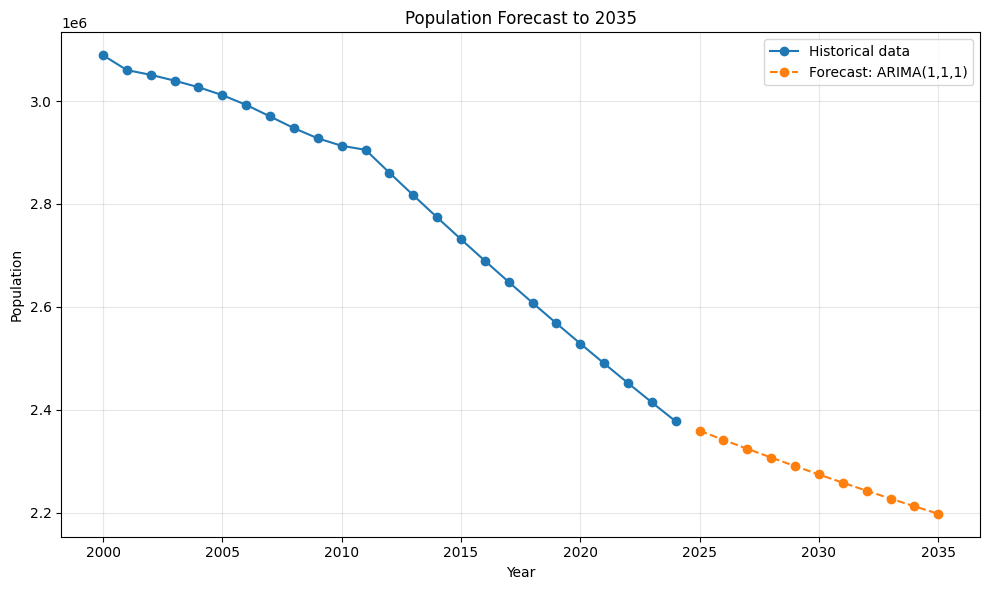

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\visuals\forecast_population_total_2035.png


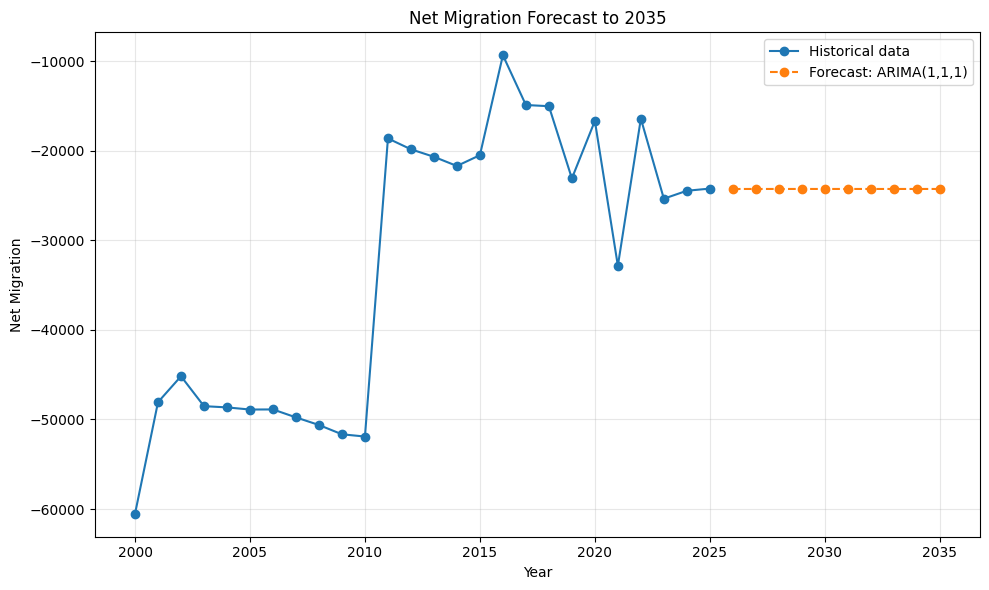

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\visuals\forecast_net_migration_2035.png


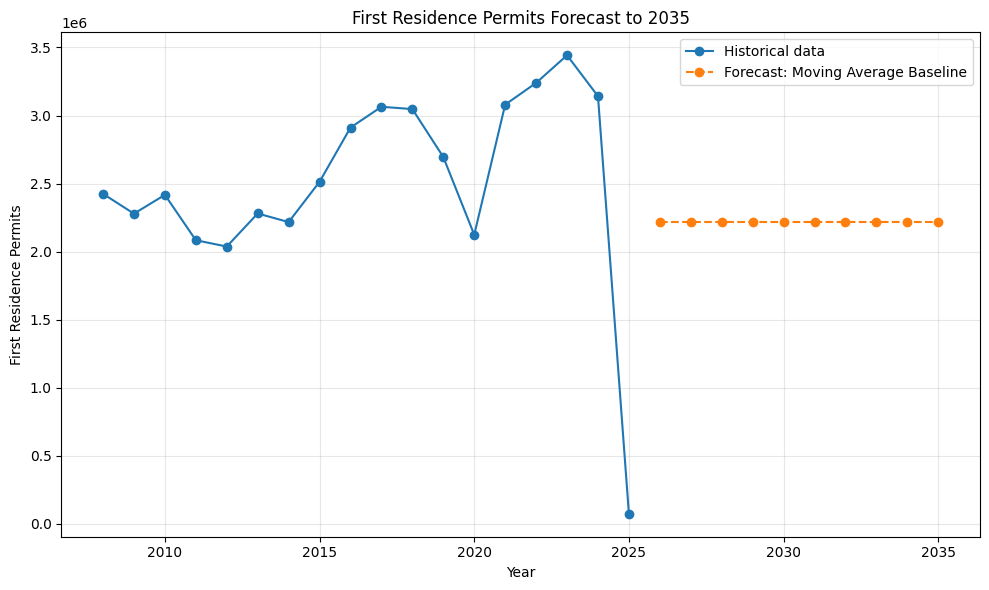

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\visuals\forecast_total_first_residence_permits_2035.png


In [14]:
for column, label in available_forecast_variables.items():
    plot_forecast(
        master,
        forecast_results,
        column,
        label,
        best_models
    )

## Create Forecast Summary Table

In [15]:
forecast_2035_summary = (
    forecast_results
    .merge(
        best_models[["indicator", "model"]],
        on=["indicator", "model"],
        how="inner"
    )
)

forecast_2035_only = forecast_2035_summary[
    forecast_2035_summary["year"] == 2035
].copy()

forecast_2035_only = forecast_2035_only[
    [
        "indicator",
        "indicator_label",
        "model",
        "year",
        "forecast_value"
    ]
]

forecast_2035_only

,indicator,indicator_label,model,year,forecast_value
10,population_total,Population,"ARIMA(1,1,1)",2035,2.197519e+06
20,net_migration,Net Migration,"ARIMA(1,1,1)",2035,-2.427148e+04
30,total_first_residence_permits,First Residence Permits,Moving Average Baseline,2035,2.219822e+06


In [16]:
forecast_2035_summary_path = PROCESSED_DIR / "forecast_2035_summary.csv"

forecast_2035_only.to_csv(forecast_2035_summary_path, index=False)

print("Saved:", forecast_2035_summary_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed\forecast_2035_summary.csv


## Generate Forecasting Report

In [17]:
def df_to_markdown_safe(df):
    try:
        return df.to_markdown(index=False)
    except Exception:
        return df.to_string(index=False)


forecast_report_path = REPORTS_DIR / "forecasting_report.md"

report_lines = []

report_lines.append("# Forecasting Report")
report_lines.append("")
report_lines.append("## Project")
report_lines.append("")
report_lines.append("Albania’s Brain Drain: A Data-Driven Analysis of Migration, Employment and Economic Development")
report_lines.append("")
report_lines.append("## Purpose")
report_lines.append("")
report_lines.append("This report presents simple forecasts to 2035 for key indicators related to Albania's brain drain analysis.")
report_lines.append("")
report_lines.append("The forecasted indicators are:")
report_lines.append("")
for _, label in available_forecast_variables.items():
    report_lines.append(f"- {label}")
report_lines.append("")

report_lines.append("## Models Used")
report_lines.append("")
report_lines.append("Three forecasting approaches were used:")
report_lines.append("")
report_lines.append("1. Moving Average Baseline")
report_lines.append("2. Linear Regression")
report_lines.append("3. ARIMA(1,1,1)")
report_lines.append("")

report_lines.append("## Model Comparison")
report_lines.append("")
report_lines.append(df_to_markdown_safe(model_comparison))
report_lines.append("")

report_lines.append("## Best Model by Indicator")
report_lines.append("")
report_lines.append(df_to_markdown_safe(best_models))
report_lines.append("")

report_lines.append("## 2035 Forecast Summary")
report_lines.append("")
report_lines.append(df_to_markdown_safe(forecast_2035_only))
report_lines.append("")

report_lines.append("## Interpretation")
report_lines.append("")
report_lines.append("The forecasts provide a simple trend-based view of how population, net migration, and residence permits may evolve by 2035 if historical patterns continue.")
report_lines.append("")
report_lines.append("These forecasts should not be interpreted as exact predictions. Migration and population trends can change due to economic policy, education opportunities, labour-market conditions, international migration rules, wages, political conditions, and unexpected shocks.")
report_lines.append("")

report_lines.append("## Limitations")
report_lines.append("")
report_lines.append("- The project uses annual public data, which may have missing values for some indicators.")
report_lines.append("- ARIMA may be unstable when the time series is short.")
report_lines.append("- Linear Regression assumes a simple trend over time and may miss structural changes.")
report_lines.append("- Moving Average is useful as a baseline but does not capture long-term changes.")
report_lines.append("- Forecasting migration is especially uncertain because migration depends on both Albanian conditions and destination-country policies.")
report_lines.append("- Working-age and elderly population forecasts require additional cleaning of the population estimates dataset, which will be handled in a later demographic analysis step.")
report_lines.append("")

report_lines.append("## Visuals Created")
report_lines.append("")
for column in available_forecast_variables.keys():
    report_lines.append(f"- forecast_{column}_2035.png")
report_lines.append("")

with open(forecast_report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Saved:", forecast_report_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\reports\forecasting_report.md


## Check Outputs

In [18]:
print("Forecast processed files:")
for file in PROCESSED_DIR.glob("forecast*.csv"):
    print("-", file.name)

print("\nForecast visuals:")
for file in VISUALS_DIR.glob("forecast*.png"):
    print("-", file.name)

print("\nForecast reports:")
for file in REPORTS_DIR.glob("*forecast*"):
    print("-", file.name)

Forecast processed files:
- forecast_2035_summary.csv
- forecast_best_models.csv
- forecast_model_comparison.csv
- forecast_results_2035.csv

Forecast visuals:
- forecast_net_migration_2035.png
- forecast_population_total_2035.png
- forecast_total_first_residence_permits_2035.png

Forecast reports:
- forecasting_report.md
